In [1]:
# ================================================================
# CELL 1: Mount Google Drive
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ================================================================
# CELL 2: Extract Dataset and Install
# ================================================================

import zipfile
import os

zip_path = "/content/drive/MyDrive/Research/dataset/dataset_500/dataset.zip"
extract_path = "/content/data/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

DATASET_PATH = "/content/data/dataset"

for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        subfolder = os.path.join(root, d)
        if any(f.endswith('.tif') for f in os.listdir(subfolder)):
            DATASET_PATH = root
            break

print(f"Dataset path: {DATASET_PATH}")
print(f"Classes: {sorted(os.listdir(DATASET_PATH))}")

!pip install rasterio opencv-python cma

Dataset path: /content/data/dataset
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 7.1 MB/s eta 0:00:00


In [3]:
# ================================================================
# CELL 3: Imports
# ================================================================

import os
import gc
import json
import pickle
import numpy as np
import rasterio
import cv2
import cma
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

SAVE_DIR = "/content/drive/MyDrive/Research/cmaes_results/FINAL_13band_5000"
MASTER_RESULTS_FILE = "/content/drive/MyDrive/Research/all_experiment_results/master_results.json"
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "cma_checkpoint.pkl")
os.makedirs(SAVE_DIR, exist_ok=True)

print("All imports done!")
print(f"Results folder: {SAVE_DIR}")

All imports done!
Results folder: /content/drive/MyDrive/Research/cmaes_results/FINAL_13band_5000


In [4]:
# ================================================================
# CELL 4: Load Dataset (13-band, 5000 images)
# ================================================================

IMG_SIZE = 64

def load_13band_image(tif_path):
    with rasterio.open(tif_path) as src:
        if src.count < 13:
            raise ValueError(f"{tif_path} has {src.count} bands, expected 13.")
        img = src.read(list(range(1, 14))).astype(np.float32)
    img = np.transpose(img, (1, 2, 0))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img / 10000.0
    return img

X = []
y = []

class_names = sorted(os.listdir(DATASET_PATH))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("Class mapping:")
for k, v in class_to_idx.items():
    print(f"  {k} → {v}")

for class_name in class_names:
    class_folder = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_folder):
        continue
    label = class_to_idx[class_name]
    for file in os.listdir(class_folder):
        if file.endswith(".tif"):
            img_path = os.path.join(class_folder, file)
            img = load_13band_image(img_path)
            X.append(img)
            y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"\nDataset: X={X.shape}, y={y.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

del X, y, X_temp, y_temp
gc.collect()

X_train = X_train.astype(np.float16)
X_val = X_val.astype(np.float16)
X_test = X_test.astype(np.float16)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Class mapping:
  AnnualCrop → 0
  Forest → 1
  HerbaceousVegetation → 2
  Highway → 3
  Industrial → 4
  Pasture → 5
  PermanentCrop → 6
  Residential → 7
  River → 8
  SeaLake → 9

Dataset: X=(5000, 64, 64, 13), y=(5000,)
Train: (3500, 64, 64, 13)
Validation: (750, 64, 64, 13)
Test: (750, 64, 64, 13)


In [5]:
# ================================================================
# CELL 5: Model Building Function
# ================================================================

activation_map = {
    0: "relu",
    1: "tanh"
}

def build_cnn_model(
    input_shape,
    num_classes,
    num_conv_layers,
    filters_list,
    kernel_size,
    activation,
    dropout_rate
):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    for i in range(num_conv_layers):
        model.add(
            layers.Conv2D(
                filters=filters_list[i],
                kernel_size=(kernel_size, kernel_size),
                padding="same",
                activation=activation
            )
        )
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation=activation))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model building function ready!")

Model building function ready!


In [6]:
# ================================================================
# CELL 6: CMA-ES Search Space and Decode Function
# ================================================================

BOUNDS = {
    "num_conv_layers": (1, 3),
    "filters_1": (16, 64),
    "filters_2": (32, 128),
    "filters_3": (64, 256),
    "kernel_size": (3, 5),
    "activation_id": (0, 1),
    "dropout_rate": (0.0, 0.5)
}

def decode_architecture(x):
    num_conv_layers = int(np.clip(round(x[0]), *BOUNDS["num_conv_layers"]))
    filters_1 = int(np.clip(round(x[1]), *BOUNDS["filters_1"]))
    filters_2 = int(np.clip(round(x[2]), *BOUNDS["filters_2"]))
    filters_3 = int(np.clip(round(x[3]), *BOUNDS["filters_3"]))
    kernel_size = int(np.clip(round(x[4]), *BOUNDS["kernel_size"]))
    activation_id = int(np.clip(round(x[5]), *BOUNDS["activation_id"]))
    activation = activation_map[activation_id]
    dropout_rate = float(np.clip(x[6], *BOUNDS["dropout_rate"]))

    filters_list = [filters_1]
    if num_conv_layers > 1:
        filters_list.append(filters_2)
    if num_conv_layers > 2:
        filters_list.append(filters_3)

    return {
        "num_conv_layers": num_conv_layers,
        "filters_list": filters_list,
        "kernel_size": kernel_size,
        "activation": activation,
        "dropout_rate": dropout_rate
    }

print("Search space ready!")

Search space ready!


In [7]:
# ================================================================
# CELL 7: FINAL CMA-ES Search WITH CHECKPOINT/RESUME
#
# 20 generations, 20 population, 15 epochs per candidate
# Runs 5 generations per chunk → 4 restarts total
#
# After each chunk:
#   1. It prints "⚠️  NOW DO THIS:"
#   2. Go to Runtime → Restart runtime
#   3. Run ALL cells from Cell 1 to Cell 7 again
#   4. It auto-resumes from where it stopped
#   5. Repeat until all 20 generations are done
# ================================================================

# --- FINAL EXPERIMENT SETTINGS ---
TOTAL_GENERATIONS = 20
GENS_PER_CHUNK = 5
POPSIZE = 20
EPOCHS_PER_CANDIDATE = 15

x0 = [3, 32, 64, 128, 3, 0, 0.5]
sigma = 0.5

print("=" * 60)
print("  🏆 FINAL CMA-ES EXPERIMENT")
print(f"  Config: 13-band Multispectral, 5000 images")
print(f"  Generations: {TOTAL_GENERATIONS}")
print(f"  Population: {POPSIZE}")
print(f"  Epochs per candidate: {EPOCHS_PER_CANDIDATE}")
print(f"  Total architectures: {TOTAL_GENERATIONS * POPSIZE}")
print(f"  Chunks of {GENS_PER_CHUNK} gens → {TOTAL_GENERATIONS // GENS_PER_CHUNK} restarts")
print("=" * 60)

# --- LOAD OR CREATE CMA-ES STATE ---
if os.path.exists(CHECKPOINT_PATH):
    print("\n📂 Loading checkpoint...")
    with open(CHECKPOINT_PATH, 'rb') as f:
        checkpoint = pickle.load(f)

    es = checkpoint['es']
    best_val_accuracy = checkpoint['best_val_accuracy']
    best_architecture = checkpoint['best_architecture']
    completed_generations = checkpoint['completed_generations']
    all_search_results = checkpoint['all_search_results']
    print(f"✅ Resuming from generation {completed_generations + 1}")
    print(f"🏆 Best so far: {best_val_accuracy:.4f}")
    if best_architecture:
        for k, v in best_architecture.items():
            print(f"   {k}: {v}")
else:
    print("\n🆕 Starting fresh FINAL CMA-ES search...")
    es = cma.CMAEvolutionStrategy(x0, sigma, {
        "popsize": POPSIZE,
        "verb_log": 0
    })
    best_val_accuracy = 0.0
    best_architecture = None
    completed_generations = 0
    all_search_results = []

# --- FITNESS FUNCTION ---
def fitness_function(x):
    global best_val_accuracy, best_architecture, all_search_results

    tf.keras.backend.clear_session()
    gc.collect()

    arch = decode_architecture(x)

    print(f"  Layers: {arch['num_conv_layers']}, Filters: {arch['filters_list']}, "
          f"Kernel: {arch['kernel_size']}, Act: {arch['activation']}, "
          f"Drop: {arch['dropout_rate']:.2f}")

    model = build_cnn_model(
        input_shape=(64, 64, 13),
        num_classes=10,
        num_conv_layers=arch["num_conv_layers"],
        filters_list=arch["filters_list"],
        kernel_size=arch["kernel_size"],
        activation=arch["activation"],
        dropout_rate=arch["dropout_rate"]
    )

    model.fit(
        X_train, y_train,
        epochs=EPOCHS_PER_CANDIDATE,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"  Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_accuracy:
        best_val_accuracy = float(val_acc)
        best_architecture = {
            'num_conv_layers': arch['num_conv_layers'],
            'filters_list': arch['filters_list'],
            'kernel_size': arch['kernel_size'],
            'activation': arch['activation'],
            'dropout_rate': arch['dropout_rate']
        }
        try:
            model.save(os.path.join(SAVE_DIR, 'best_model_search.h5'))
            print(f"  💾 New best! Saved.")
        except Exception as e:
            print(f"  Could not save: {e}")

    fitness = 1.0 - val_acc

    all_search_results.append({
        'generation': completed_generations + 1,
        'architecture': arch,
        'val_acc': float(val_acc)
    })

    del model
    gc.collect()

    return fitness

# --- RUN GENERATIONS ---
remaining = TOTAL_GENERATIONS - completed_generations
gens_to_run = min(GENS_PER_CHUNK, remaining)

if gens_to_run <= 0:
    print(f"\n🏁 ALL {TOTAL_GENERATIONS} GENERATIONS ALREADY COMPLETED!")
    print(f"🏆 Best Validation Accuracy: {best_val_accuracy:.4f}")
    if best_architecture:
        for k, v in best_architecture.items():
            print(f"   {k}: {v}")
    print("\n👉 Now run Cell 8 to retrain the best architecture.")
else:
    print(f"\n🚀 Running generations {completed_generations+1} to {completed_generations+gens_to_run} out of {TOTAL_GENERATIONS}")

    for g in range(gens_to_run):
        gen_num = completed_generations + g + 1
        print(f"\n{'='*50}")
        print(f"  Generation {gen_num}/{TOTAL_GENERATIONS}")
        print(f"{'='*50}")

        solutions = es.ask()
        fitnesses = []

        for i, x in enumerate(solutions):
            print(f"\n--- Candidate {i+1}/{POPSIZE} (Gen {gen_num}) ---")
            f = fitness_function(x)
            fitnesses.append(f)

        es.tell(solutions, fitnesses)
        es.disp()
        print(f"\n🏆 Best after Gen {gen_num}: {best_val_accuracy:.4f}")

    completed_generations += gens_to_run

    # --- SAVE CHECKPOINT ---
    checkpoint = {
        'es': es,
        'best_val_accuracy': best_val_accuracy,
        'best_architecture': best_architecture,
        'completed_generations': completed_generations,
        'all_search_results': all_search_results
    }
    with open(CHECKPOINT_PATH, 'wb') as f:
        pickle.dump(checkpoint, f)

    # Save search results too
    search_data = {
        'config': 'FINAL - 13-band Multispectral, 5000 images',
        'generations': TOTAL_GENERATIONS,
        'population': POPSIZE,
        'epochs_per_candidate': EPOCHS_PER_CANDIDATE,
        'completed_generations': completed_generations,
        'best_val_accuracy': best_val_accuracy,
        'best_architecture': best_architecture,
        'all_results': all_search_results
    }
    with open(os.path.join(SAVE_DIR, 'search_results.json'), 'w') as f:
        json.dump(search_data, f, indent=2)

    print(f"\n{'='*50}")
    print(f"💾 CHECKPOINT SAVED!")
    print(f"   Completed: {completed_generations}/{TOTAL_GENERATIONS} generations")
    print(f"   Architectures evaluated: {len(all_search_results)}")
    print(f"   Best accuracy: {best_val_accuracy:.4f}")
    if best_architecture:
        for k, v in best_architecture.items():
            print(f"   {k}: {v}")
    print(f"{'='*50}")

    if completed_generations < TOTAL_GENERATIONS:
        remaining_chunks = (TOTAL_GENERATIONS - completed_generations + GENS_PER_CHUNK - 1) // GENS_PER_CHUNK
        print(f"\n⚠️  NOW DO THIS:")
        print(f"   1. Go to Runtime → Restart runtime")
        print(f"   2. Run ALL cells again (Cell 1 through Cell 7)")
        print(f"   3. It will auto-resume from generation {completed_generations+1}")
        print(f"   4. {remaining_chunks} more restart(s) needed after this")
    else:
        print(f"\n🏁 ALL {TOTAL_GENERATIONS} GENERATIONS COMPLETE!")
        print(f"   Total architectures evaluated: {len(all_search_results)}")
        print(f"\n👉 Now run Cell 8 to retrain the best architecture for 150 epochs.")

  🏆 FINAL CMA-ES EXPERIMENT
  Config: 13-band Multispectral, 5000 images
  Generations: 20
  Population: 20
  Epochs per candidate: 15
  Total architectures: 400
  Chunks of 5 gens → 4 restarts

📂 Loading checkpoint...
✅ Resuming from generation 16
🏆 Best so far: 0.9053
   num_conv_layers: 3
   filters_list: [33, 64, 128]
   kernel_size: 3
   activation: relu
   dropout_rate: 0.5

🚀 Running generations 16 to 20 out of 20

  Generation 16/20

--- Candidate 1/20 (Gen 16) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8600

--- Candidate 2/20 (Gen 16) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8600

--- Candidate 3/20 (Gen 16) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8293

--- Candidate 4/20 (Gen 16) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8693

--- Candidate 5/20 (Gen 16) ---
  Layers: 3, Filte

  Val Accuracy: 0.9093
  💾 New best! Saved.

--- Candidate 8/20 (Gen 17) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8707

--- Candidate 9/20 (Gen 17) ---
  Layers: 3, Filters: [33, 64, 127], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8747

--- Candidate 10/20 (Gen 17) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8800

--- Candidate 11/20 (Gen 17) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8427

--- Candidate 12/20 (Gen 17) ---
  Layers: 3, Filters: [32, 64, 127], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8840

--- Candidate 13/20 (Gen 17) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8600

--- Candidate 14/20 (Gen 17) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8760

--- Candidate 15/20 (Gen 17) ---
  Layers: 3, Filters: [32, 64, 128]

In [8]:
# ================================================================
# CELL 8: Retrain Best CMA-ES Architecture (150 epochs)
# ⚠️ ONLY RUN THIS AFTER ALL 20 GENERATIONS ARE COMPLETE
# ================================================================

print("=" * 60)
print("  🏆 FINAL RETRAINING: BEST CMA-ES ARCHITECTURE (150 epochs)")
print("  Config: 13-band Multispectral, 5000 images")
print("=" * 60)

tf.keras.backend.clear_session()
gc.collect()

# Load best architecture if needed
if best_architecture is None:
    with open(os.path.join(SAVE_DIR, 'search_results.json'), 'r') as f:
        search_data = json.load(f)
    best_architecture = search_data['best_architecture']
    best_val_accuracy = search_data['best_val_accuracy']
    all_search_results = search_data['all_results']

print(f"\nBest Architecture from search:")
for k, v in best_architecture.items():
    print(f"  {k}: {v}")
print(f"  Search val accuracy: {best_val_accuracy:.4f}")

cmaes_model = build_cnn_model(
    input_shape=(64, 64, 13),
    num_classes=10,
    num_conv_layers=best_architecture['num_conv_layers'],
    filters_list=best_architecture['filters_list'],
    kernel_size=best_architecture['kernel_size'],
    activation=best_architecture['activation'],
    dropout_rate=best_architecture['dropout_rate']
)

cmaes_model.summary()

my_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

history_cmaes = cmaes_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=my_callbacks,
    verbose=1
)

cmaes_val_loss, cmaes_val_acc = cmaes_model.evaluate(X_val, y_val, verbose=0)
cmaes_test_loss, cmaes_test_acc = cmaes_model.evaluate(X_test, y_test, verbose=0)

print(f"\n📊 CMA-ES Validation Accuracy: {cmaes_val_acc:.4f}")
print(f"📊 CMA-ES Test Accuracy:       {cmaes_test_acc:.4f}")

y_pred_cmaes = np.argmax(cmaes_model.predict(X_test), axis=1)

cmaes_model.save(os.path.join(SAVE_DIR, 'cmaes_final_model.h5'))

cmaes_history = {
    'accuracy': [float(x) for x in history_cmaes.history['accuracy']],
    'val_accuracy': [float(x) for x in history_cmaes.history['val_accuracy']],
    'loss': [float(x) for x in history_cmaes.history['loss']],
    'val_loss': [float(x) for x in history_cmaes.history['val_loss']],
}
with open(os.path.join(SAVE_DIR, 'cmaes_final_training_history.json'), 'w') as f:
    json.dump(cmaes_history, f)

cmaes_report = classification_report(
    y_test, y_pred_cmaes,
    target_names=class_names,
    digits=4,
    output_dict=True
)

del cmaes_model
gc.collect()

print("✅ Final CMA-ES retraining complete!")

  🏆 FINAL RETRAINING: BEST CMA-ES ARCHITECTURE (150 epochs)
  Config: 13-band Multispectral, 5000 images

Best Architecture from search:
  num_conv_layers: 3
  filters_list: [32, 64, 128]
  kernel_size: 3
  activation: relu
  dropout_rate: 0.5
  Search val accuracy: 0.9093


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,146,122 (4.37 MB)

 Trainable params: 1,146,122 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.3860 - loss: 1.6367 - val_accuracy: 0.5520 - val_loss: 1.2005 - learning_rate: 0.0010
Epoch 2/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5249 - loss: 1.2559 - val_accuracy: 0.6027 - val_loss: 1.0590 - learning_rate: 0.0010
Epoch 3/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5960 - loss: 1.0969 - val_accuracy: 0.6360 - val_loss: 0.9931 - learning_rate: 0.0010
Epoch 4/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6400 - loss: 0.9964 - val_accuracy: 0.7027 - val_loss: 0.8121 - learning_rate: 0.0010
Epoch 5/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6746 - loss: 0.8808 - val_accuracy: 0.7400 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 6/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7254 - loss: 0.7869 - val_accuracy: 0.7267 - val_loss: 0.6853 - learning_rate: 0.0010
Epoch 7/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7566 - l

✅ Final CMA-ES retraining complete!


In [9]:
# ================================================================
# CELL 9: Load Baseline and Compare
# ================================================================

print("=" * 60)
print("  🏆 FINAL COMPARISON: BASELINE vs CMA-ES")
print("  Config: 13-band Multispectral, 5000 images (FINAL)")
print("=" * 60)

with open(MASTER_RESULTS_FILE, 'r') as f:
    master_data = json.load(f)

baseline_entry = next(
    (r for r in master_data['experiments']
     if r['num_bands'] == 13 and r['num_images'] == '5000'),
    None
)

if baseline_entry is None:
    print("❌ Baseline result for 13-band 5000 not found!")
    baseline_val_acc = 0
    baseline_test_acc = 0
    baseline_f1 = 0
else:
    baseline_val_acc = baseline_entry['val_accuracy']
    baseline_test_acc = baseline_entry['test_accuracy']
    baseline_f1 = baseline_entry['macro_f1']

# Full classification report
print("\nCMA-ES CNN Classification Report:")
print(classification_report(y_test, y_pred_cmaes, target_names=class_names, digits=4))

# Comparison table
print(f"\n{'='*65}")
print(f"{'Metric':<25} {'Baseline':>12} {'CMA-ES':>12} {'Difference':>12}")
print("-" * 65)
print(f"{'Validation Accuracy':<25} {baseline_val_acc:>12.4f} {cmaes_val_acc:>12.4f} {cmaes_val_acc - baseline_val_acc:>+12.4f}")
print(f"{'Test Accuracy':<25} {baseline_test_acc:>12.4f} {cmaes_test_acc:>12.4f} {cmaes_test_acc - baseline_test_acc:>+12.4f}")
print(f"{'Macro F1-Score':<25} {baseline_f1:>12.4f} {cmaes_report['macro avg']['f1-score']:>12.4f} {cmaes_report['macro avg']['f1-score'] - baseline_f1:>+12.4f}")
print(f"{'Macro Precision':<25} {'---':>12} {cmaes_report['macro avg']['precision']:>12.4f} {'':>12}")
print(f"{'Macro Recall':<25} {'---':>12} {cmaes_report['macro avg']['recall']:>12.4f} {'':>12}")
print("-" * 65)

# Per-class
if baseline_entry and 'per_class_f1' in baseline_entry:
    print(f"\n{'Class':<20} {'Baseline F1':>12} {'CMA-ES F1':>12} {'Diff':>12}")
    print("-" * 56)
    for cls in class_names:
        b = baseline_entry['per_class_f1'].get(cls, 0)
        c = cmaes_report[cls]['f1-score']
        print(f"{cls:<20} {b:>12.4f} {c:>12.4f} {c - b:>+12.4f}")

print(f"\n  Baseline: 3 layers, [32,64,128], kernel 3, relu, dropout 0.5")
print(f"  CMA-ES:   {best_architecture['num_conv_layers']} layers, "
      f"{best_architecture['filters_list']}, kernel {best_architecture['kernel_size']}, "
      f"{best_architecture['activation']}, dropout {best_architecture['dropout_rate']:.2f}")

  🏆 FINAL COMPARISON: BASELINE vs CMA-ES
  Config: 13-band Multispectral, 5000 images (FINAL)

CMA-ES CNN Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.8594    0.7333    0.7914        75
              Forest     0.9855    0.9067    0.9444        75
HerbaceousVegetation     0.8611    0.8267    0.8435        75
             Highway     0.7215    0.7600    0.7403        75
          Industrial     0.9189    0.9067    0.9128        75
             Pasture     0.7614    0.8933    0.8221        75
       PermanentCrop     0.8209    0.7333    0.7746        75
         Residential     0.7674    0.8800    0.8199        75
               River     0.9474    0.9600    0.9536        75
             SeaLake     1.0000    1.0000    1.0000        75

            accuracy                         0.8600       750
           macro avg     0.8644    0.8600    0.8603       750
        weighted avg     0.8644    0.8600    0.8603       750



In [10]:
# ================================================================
# CELL 10: Save to Master Table
# ================================================================

# Save as special "final" entry
master_data['cmaes_experiments']['FINAL_13-band_5000'] = {
    'val_accuracy': float(cmaes_val_acc),
    'test_accuracy': float(cmaes_test_acc),
    'macro_f1': float(cmaes_report['macro avg']['f1-score']),
    'macro_precision': float(cmaes_report['macro avg']['precision']),
    'macro_recall': float(cmaes_report['macro avg']['recall']),
    'architecture': best_architecture,
    'search_config': {
        'generations': TOTAL_GENERATIONS,
        'population': POPSIZE,
        'epochs_per_candidate': EPOCHS_PER_CANDIDATE,
        'total_evaluated': len(all_search_results),
        'final_retrain_epochs': 150
    },
    'per_class_f1': {cls: float(cmaes_report[cls]['f1-score']) for cls in class_names}
}

with open(MASTER_RESULTS_FILE, 'w') as f:
    json.dump(master_data, f, indent=2)

print(f"💾 FINAL results saved to master table!")

# Print full master table
print(f"\n{'='*80}")
print("  COMPLETE MASTER TABLE")
print(f"{'='*80}")
print(f"{'Configuration':<30} {'Baseline Test':>14} {'CMA-ES Test':>12} {'Improvement':>12}")
print("-" * 80)

cmaes_exps = master_data.get('cmaes_experiments', {})
for r in master_data.get('experiments', []):
    key = f"{r['num_bands']}-band_{r['num_images']}"
    cmaes = cmaes_exps.get(key, {})
    c_test = cmaes.get('test_accuracy')

    c_str = f"{c_test:.4f}" if c_test else "---"
    diff_str = f"{c_test - r['test_accuracy']:+.4f}" if c_test else "---"
    label = f"{r['num_bands']}-band, {r['num_images']} imgs"

    print(f"{label:<30} {r['test_accuracy']:>14.4f} {c_str:>12} {diff_str:>12}")

# Print final entry
final = cmaes_exps.get('FINAL_13-band_5000', {})
if final.get('test_accuracy'):
    print(f"{'FINAL 13-band, 5000 imgs':<30} {baseline_test_acc:>14.4f} {final['test_accuracy']:>12.4f} {final['test_accuracy'] - baseline_test_acc:>+12.4f}")

print("-" * 80)

💾 FINAL results saved to master table!

  COMPLETE MASTER TABLE
Configuration                   Baseline Test  CMA-ES Test  Improvement
--------------------------------------------------------------------------------
3-band, 1000 imgs                      0.6800       0.6733      -0.0067
13-band, 1000 imgs                     0.8267       0.7933      -0.0333
3-band, 5000 imgs                      0.8067       0.7813      -0.0253
13-band, 5000 imgs                     0.8960       0.8760      -0.0200
FINAL 13-band, 5000 imgs               0.8960       0.8600      -0.0360
--------------------------------------------------------------------------------


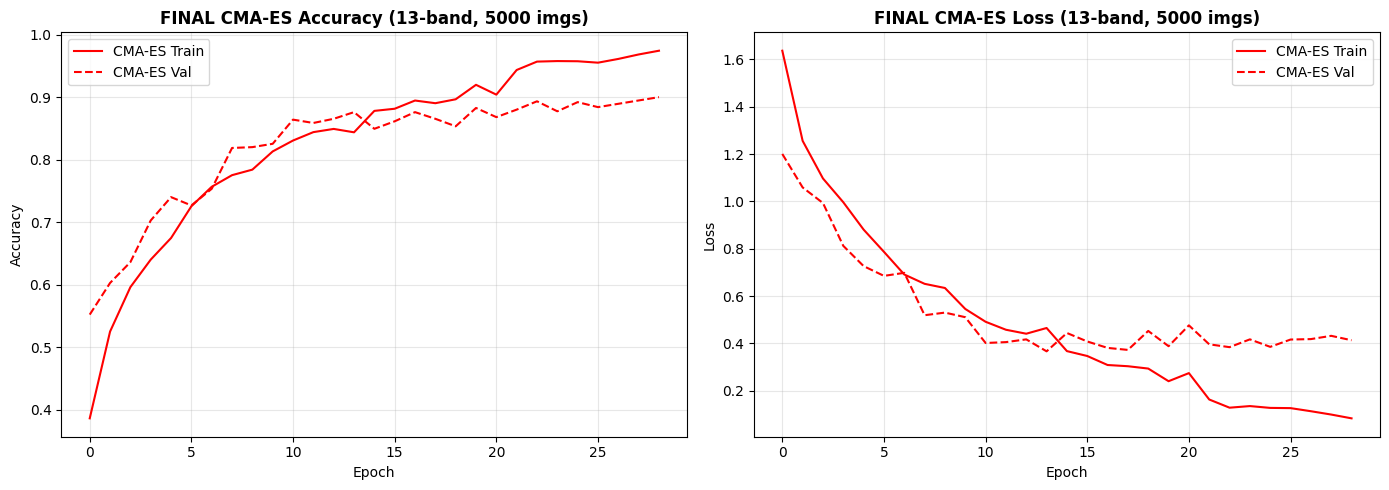

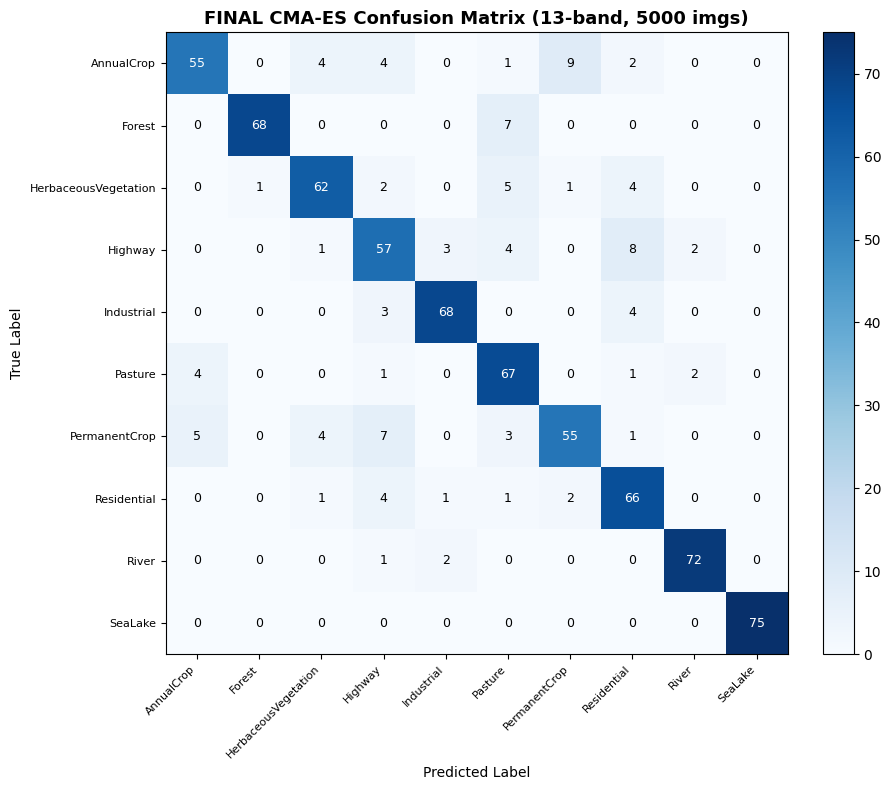

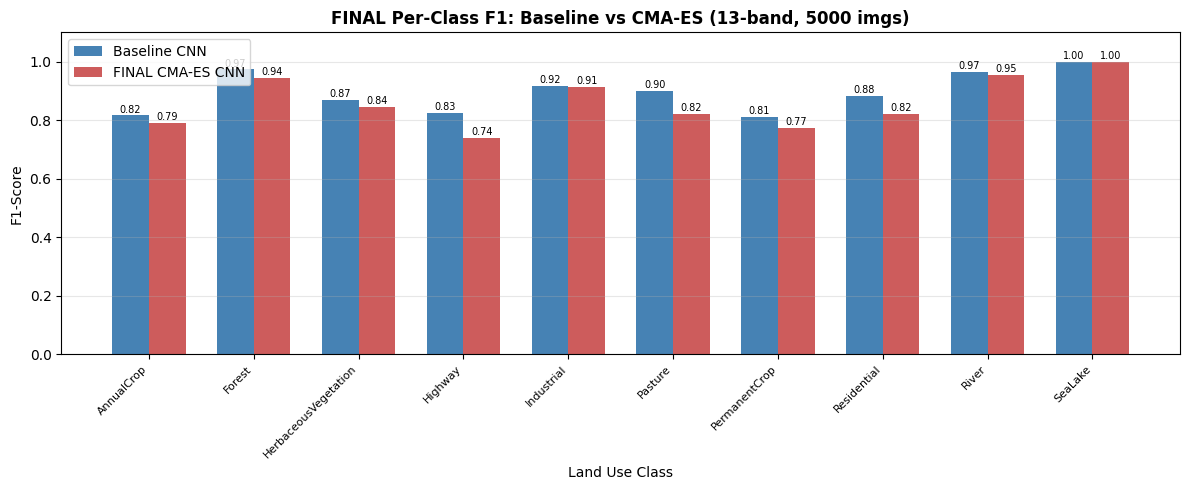

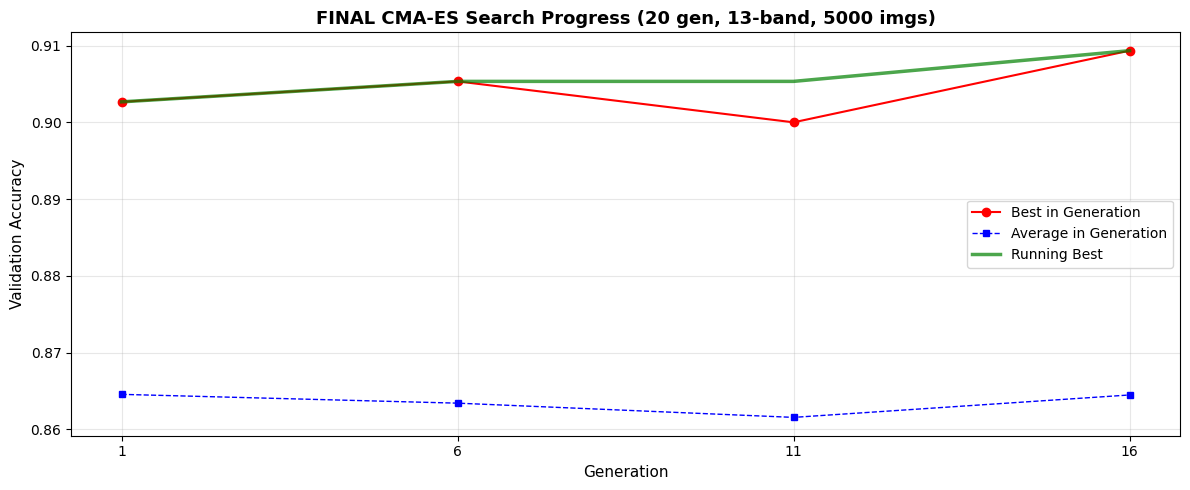


💾 All charts saved to /content/drive/MyDrive/Research/cmaes_results/FINAL_13band_5000


In [11]:
# ================================================================
# CELL 11: Generate All Charts
# ================================================================

# ---- 1. Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cmaes_history['accuracy'], label='CMA-ES Train', linestyle='-', color='red')
axes[0].plot(cmaes_history['val_accuracy'], label='CMA-ES Val', linestyle='--', color='red')
axes[0].set_title('FINAL CMA-ES Accuracy (13-band, 5000 imgs)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cmaes_history['loss'], label='CMA-ES Train', linestyle='-', color='red')
axes[1].plot(cmaes_history['val_loss'], label='CMA-ES Val', linestyle='--', color='red')
axes[1].set_title('FINAL CMA-ES Loss (13-band, 5000 imgs)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'final_training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

# ---- 2. Confusion matrix ----
cm_cmaes = confusion_matrix(y_test, y_pred_cmaes)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_cmaes, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('FINAL CMA-ES Confusion Matrix (13-band, 5000 imgs)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

thresh = cm_cmaes.max() / 2.0
for i in range(cm_cmaes.shape[0]):
    for j in range(cm_cmaes.shape[1]):
        ax.text(j, i, format(cm_cmaes[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_cmaes[i, j] > thresh else "black", fontsize=9)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'final_confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

# ---- 3. Per-class F1 comparison ----
if baseline_entry and 'per_class_f1' in baseline_entry:
    fig, ax = plt.subplots(figsize=(12, 5))

    b_f1 = [baseline_entry['per_class_f1'].get(cls, 0) for cls in class_names]
    c_f1 = [cmaes_report[cls]['f1-score'] for cls in class_names]
    x = np.arange(len(class_names))
    width = 0.35

    ax.bar(x - width/2, b_f1, width, label='Baseline CNN', color='steelblue')
    ax.bar(x + width/2, c_f1, width, label='FINAL CMA-ES CNN', color='indianred')
    ax.set_xlabel('Land Use Class')
    ax.set_ylabel('F1-Score')
    ax.set_title('FINAL Per-Class F1: Baseline vs CMA-ES (13-band, 5000 imgs)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(True, axis='y', alpha=0.3)

    for i in range(len(class_names)):
        ax.text(i - width/2, b_f1[i] + 0.01, f'{b_f1[i]:.2f}', ha='center', fontsize=7)
        ax.text(i + width/2, c_f1[i] + 0.01, f'{c_f1[i]:.2f}', ha='center', fontsize=7)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'final_per_class_f1.png'), dpi=200, bbox_inches='tight')
    plt.show()

# ---- 4. Search progress across all 20 generations ----
fig, ax = plt.subplots(figsize=(12, 5))

gen_numbers = []
gen_best = []
gen_avg = []
running_best = []
current_best = 0

for gen in range(1, completed_generations + 1):
    gen_results = [r for r in all_search_results if r['generation'] == gen]
    if gen_results:
        gen_numbers.append(gen)
        best_in_gen = max(r['val_acc'] for r in gen_results)
        gen_best.append(best_in_gen)
        gen_avg.append(np.mean([r['val_acc'] for r in gen_results]))
        current_best = max(current_best, best_in_gen)
        running_best.append(current_best)

ax.plot(gen_numbers, gen_best, 'ro-', label='Best in Generation', linewidth=1.5, markersize=6)
ax.plot(gen_numbers, gen_avg, 'bs--', label='Average in Generation', linewidth=1, markersize=5)
ax.plot(gen_numbers, running_best, 'g-', label='Running Best', linewidth=2.5, alpha=0.7)
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('FINAL CMA-ES Search Progress (20 gen, 13-band, 5000 imgs)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(gen_numbers)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'final_search_progress.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"\n💾 All charts saved to {SAVE_DIR}")

In [ ]:
# ================================================================
# CELL 12: Final Summary
# ================================================================

print("=" * 60)
print("  🏆 FINAL EXPERIMENT — COMPLETE RESULTS")
print("  CMA-ES, 13-band Multispectral, 5000 images")
print("=" * 60)

print(f"""
DATASET:
  Total images: 5,000 (500 per class)
  Training: {X_train.shape[0]}
  Validation: {X_val.shape[0]}
  Test: {X_test.shape[0]}
  Input shape: (64, 64, 13)

CMA-ES SEARCH (EXTENDED):
  Generations: {TOTAL_GENERATIONS}
  Population: {POPSIZE}
  Epochs per candidate: {EPOCHS_PER_CANDIDATE}
  Total architectures evaluated: {len(all_search_results)}
  Final retrain epochs: 150

  Best architecture found:
    Layers: {best_architecture['num_conv_layers']}
    Filters: {best_architecture['filters_list']}
    Kernel: {best_architecture['kernel_size']}
    Activation: {best_architecture['activation']}
    Dropout: {best_architecture['dropout_rate']}

BASELINE CNN:
  Architecture: 3 layers, [32,64,128], kernel 3, relu, dropout 0.5
  Validation Accuracy: {baseline_val_acc:.4f}
  Test Accuracy: {baseline_test_acc:.4f}

FINAL CMA-ES CNN:
  Validation Accuracy: {cmaes_val_acc:.4f}
  Test Accuracy: {cmaes_test_acc:.4f}
  Macro F1-Score: {cmaes_report['macro avg']['f1-score']:.4f}

IMPROVEMENT:
  Validation: {cmaes_val_acc - baseline_val_acc:+.4f} ({(cmaes_val_acc - baseline_val_acc)*100:+.2f}%)
  Test:       {cmaes_test_acc - baseline_test_acc:+.4f} ({(cmaes_test_acc - baseline_test_acc)*100:+.2f}%)

FILES SAVED:
  {SAVE_DIR}/search_results.json
  {SAVE_DIR}/best_model_search.h5
  {SAVE_DIR}/cmaes_final_model.h5
  {SAVE_DIR}/cmaes_final_training_history.json
  {SAVE_DIR}/final_training_curves.png
  {SAVE_DIR}/final_confusion_matrix.png
  {SAVE_DIR}/final_per_class_f1.png
  {SAVE_DIR}/final_search_progress.png
  {MASTER_RESULTS_FILE} (updated with FINAL entry)
""")

print("🏁 ALL EXPERIMENTS COMPLETE!")

  🏆 FINAL EXPERIMENT — COMPLETE RESULTS
  CMA-ES, 13-band Multispectral, 5000 images

DATASET:
  Total images: 5,000 (500 per class)
  Training: 3500
  Validation: 750
  Test: 750
  Input shape: (64, 64, 13)

CMA-ES SEARCH (EXTENDED):
  Generations: 20
  Population: 20
  Epochs per candidate: 15
  Total architectures evaluated: 400
  Final retrain epochs: 150

  Best architecture found:
    Layers: 3
    Filters: [32, 64, 128]
    Kernel: 3
    Activation: relu
    Dropout: 0.5

BASELINE CNN:
  Architecture: 3 layers, [32,64,128], kernel 3, relu, dropout 0.5
  Validation Accuracy: 0.8693
  Test Accuracy: 0.8960

FINAL CMA-ES CNN:
  Validation Accuracy: 0.8760
  Test Accuracy: 0.8600
  Macro F1-Score: 0.8603

IMPROVEMENT:
  Validation: +0.0067 (+0.67%)
  Test:       -0.0360 (-3.60%)

FILES SAVED:
  /content/drive/MyDrive/Research/cmaes_results/FINAL_13band_5000/search_results.json
  /content/drive/MyDrive/Research/cmaes_results/FINAL_13band_5000/best_model_search.h5
  /content/drive/MyD